# Chapter 39. Hyperparameters and Model Validation

The following is the recipe we have discussed for implementing a supervised ML model:

1. Choose the model class.
2. Choose the model hyperparameters.
3. Fit the model to the training data.
4. Use the model to predict labels for new data.

The first two pieces of this are critical decisions, important to the effective implementation of the model in question.

To make informed choices about hte model, we must _validate_ our model and our hyperparameters.

## How to validate our models

The general idea is simple: after choosing a model and its hyperparameters, we can estimate how effective that model is by applying it to some of the data.

## Model validation done wrong

A naive approach would be to apply the trained model to the training data and check the accuracy on that set.

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

We will use a _k_-nearest neighbors classifier with `n_neighbors=1`. A very simple and intuitive model that chooses a label based on the closest training points.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)

Training the model:

In [ ]:
model.fit(X, y)
y_model = model.predict(X)

Now, we compute the accuracy of this model on the training set:

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_model)

This means that the accuracy score is 100% on the training set. Is it a measure of expected accuracy? No! The model _cannot be trained and evaluated on the same data_.

## Model Validation the right way: holdout sets

To properly evaluate a model, we can holdout some of the data points from training, and use them to measure the model's performance.

We can split the dataset using `train_test_split`, generating a subset for training and a subset for testing. In the _test_ set in this context is called _validation set_.

In [ ]:
from sklearn.model_selection import train_test_split
# split the data with 50% in each set
X1, X2, y1, y2 = train_test_split(X, y, random_state=0,
                                    train_size=0.5)

# fit the model on one set of data
model.fit(X1, y1)

# evaluate the model on the second set of data
y2_model = model.predict(X2)
accuracy_score(y2, y2_model)

This seems like a more reasonable result. The holdout set is unknown data that was never seen in training.

## Cross-validation

What is one major disadvantage of the above strategy?

Splitting the data means we have lost some of the training data to the holdout set. Thus, we are using less data for training than we could have.

One way to address this issue is to use _cross-validation_.

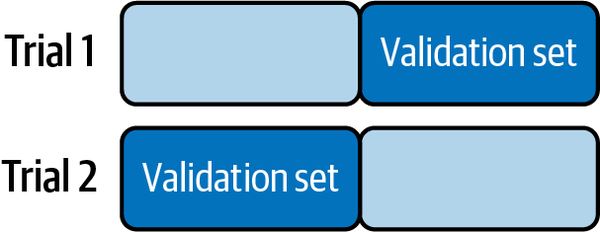

We do two validation trials, using each half of the data as the holdout set.

In [ ]:
y2_model = model.fit(X1, y1).predict(X2)
y1_model = model.fit(X2, y2).predict(X1)
accuracy_score(y1, y1_model), accuracy_score(y2, y2_model)

Then, we can combine the accuracy scores (average) to get a better measure of global model performance.

We can also split the sets into more trials, splitting the dataset into more trials.

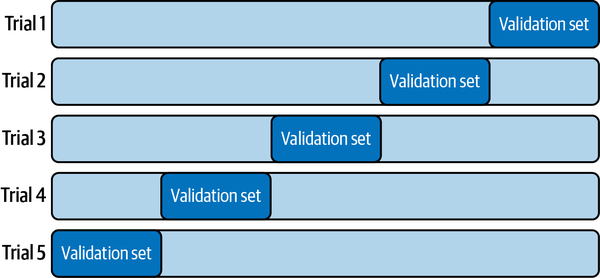

The above splits the data into five groups and use each in turn to evaluate the model fit.

Scikit-Learn provides the `cross_val_score` routine to implement cross-validation.

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

The `cv` argument controls the number of folds (trials) applied to the data. The above example does a five-fold cross-validation.

### Leave-one-out cross-validation

This is the extreme case where the number of folds is equal to the number of data points. It can be used as follows:

In [ ]:
from sklearn.model_selection import LeaveOneOut
scores = cross_val_score(model, X, y, cv=LeaveOneOut())
scores

The results consist of 0's and 1's only (why?). To get the aggregated result, we can use the mean:

In [ ]:
scores.mean()

## Selecting the best model

What if our model is underperforming in the validation? How to proceed?

- Use a more complicated model.
- Use a less complicated model.
- Gather more training samples.
- Gather more data to add features to each sample.

## The bias-variance trade-off

Sometimes, using a more complex model can lead to worse results! The best model is about finding the sweet spot in the trade-off between _bias_ and _variance_.

The following presents two fits to the same dataset:

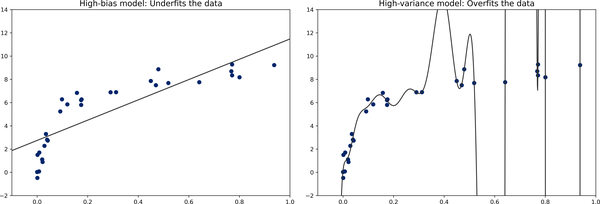

Neither of the above models present a good fit. But they fail in different ways.

The model on the left attempts to find a straight-line to describe the data. It does not accurately fits the data because it is not flexible enough fot it, leading to _underfitting_, or high bias.

The model on the right attempts to fit a high-order polynomial to the data. The model is too complex and, even though it fits every point precisely, it lacks the ability to generalize to unseen data. This is called _overfitting_, or high variance.

Consider the $R^2$ score which measures how well a model performs relative to the mean of target values. $R^2=1$ indicates a perfect match, $R^2=0$ indicates the model does not better than just taking the mean of the data.

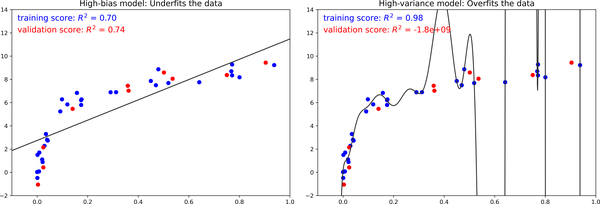

- For high-bias models, the performance on the validation is similar to the performance on the training set.
- For high-variance models, the performance on the validation is far worse than the performance on the training set.

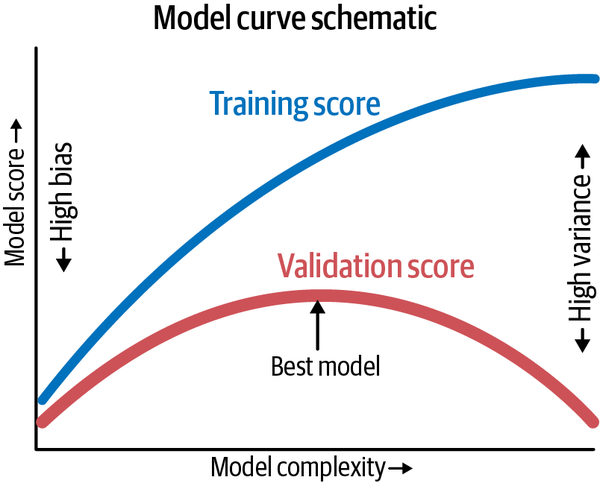

## Validation curves in Scikit-Learn

Let us use cross-validation to compute the validation curve for a few models.
We will use a _polynomial regression_ model, a generalized linear model where the degre of the polynomial is a tunable parameter.

For example, a degree-1 polynomial fits a stright line to the data:

$$y= ax+b$$

A degree-3 polynomial fits a cubic curve to the data:

$$y = ax^3 + bx^2 + cx + d$$

In Scikit-Learn, we can implement this using a `LinearRegression` classifier and a `PolynomialFeatures` preprocessor. We will use `make_pipeline` to compose a polynomial regression procedure.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),
                        LinearRegression(**kwargs))

Now, let us create some data to fit our model to:

In [ ]:
import numpy as np

def make_data(N, err=1.0, rseed=1):
    # randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

X, y = make_data(40)

Now, let us visualize the polynomial fits of several degrees.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

X_test = np.linspace(-0.1, 1.1, 500)[:, None]

plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()
for degree in [1, 3, 5]:
    y_test = PolynomialRegression(degree).fit(X, y).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label='degree={0}'.format(degree))
plt.xlim(-0.1, 1.0)
plt.ylim(-2, 12)
plt.legend(loc='best');

The model complexity is controlled by the polynomial degree. How do we know the best polynomial degree to use? That is, which degree provides the best trade-off between bias (underfitting) and variance (overfitting)?

We can look for answers by visualizing the validation curve for this particular data and model. We can use the `validation_curve` for that.

In [ ]:
from sklearn.model_selection import validation_curve
degree = np.arange(0, 21)
train_score, val_score = validation_curve(
    PolynomialRegression(), X, y,
    param_name='polynomialfeatures__degree',
    param_range=degree, cv=7)

plt.plot(degree, np.median(train_score, 1),
        color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1),
        color='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');

The curve shows that the validation scores peaks when the degree is 3. Thus, we can determine that the optimal bias-variance trade-off occurs for this choice.

Let us visualize the fit for a third-order polynomial:

In [ ]:
plt.scatter(X.ravel(), y)
lim = plt.axis()
y_test = PolynomialRegression(3).fit(X, y).predict(X_test)
plt.plot(X_test.ravel(), y_test);
plt.axis(lim);

## Grid Search: Tuning multiple parameters

In the previous example, we only had one parameter to tune (the polynomial order). In real scenarios, there are usually multiple "knobs" to turn. This means that the validation curves changes from lines to multidimensional surfaces.

`Scikit-Learn` provides tools to make this process easier.

We will repeat the above provess but searching for two different parameters: the polynomial degree (non-negative integer) and whether to fit the intercept (True/False).

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'polynomialfeatures__degree': np.arange(21),
            'linearregression__fit_intercept': [True, False]}

grid = GridSearchCV(PolynomialRegression(), param_grid, cv=7)

In [ ]:
grid.fit(X, y);

This will automatically search for the best model, we can get the best params as follows:

In [ ]:
grid.best_params_

Let us visualize the best model after fitting to the training data:

In [ ]:
model = grid.best_estimator_

plt.scatter(X.ravel(), y)
lim = plt.axis()
y_test = model.fit(X, y).predict(X_test)
plt.plot(X_test.ravel(), y_test);
plt.axis(lim);